<a href="https://colab.research.google.com/github/HenryZumaeta/py4cd_EPC2025/blob/main/C21/C21_Script01_Regularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

# Configuración de estilo para publicaciones académicas
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 12

def generate_data(n_samples=100, noise_std=0.1, random_state=42):
    """
    Genera datos sintéticos basados en una función verdadera conocida.
    """
    np.random.seed(random_state)
    X = np.linspace(0, 1, n_samples)
    # Función verdadera: f*(x) = sin(2 * pi * x)
    y_true = np.sin(2 * np.pi * X)
    # Observaciones: y = f*(x) + epsilon
    y_noise = y_true + np.random.normal(0, noise_std, n_samples)
    return X, y_true, y_noise

def create_polynomial_model(degree):
    """
    Crea un pipeline de regresión polinómica.
    """
    model = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('linear', LinearRegression())
    ])
    return model

def evaluate_model(model, X_train, y_train, X_test, y_test, y_true_func):
    """
    Entrena y evalúa el modelo retornando métricas y predicciones.
    """
    model.fit(X_train.reshape(-1, 1), y_train)

    # Predicciones
    y_train_pred = model.predict(X_train.reshape(-1, 1))
    y_test_pred = model.predict(X_test.reshape(-1, 1))

    # Errores
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)

    # Error respecto a la función verdadera (sin ruido) en el conjunto de test
    # Esto nos dice qué tan bien aprendimos la señal real
    mse_true = mean_squared_error(y_true_func(X_test), y_test_pred)

    return mse_train, mse_test, mse_true, y_test_pred

In [2]:
# Generacion de datos
X, y_true, y_obs = generate_data(n_samples = 30 , noise_std=0.1)
X_train, X_test, y_train, y_test = train_test_split(X, y_obs , test_size = 0.4, random_state=42)

# Modelos con diferente nivel de complejidad  (Grados del polinomio)
degrees = range(1,16)
train_errors = []
test_errors = []
true_errors = []

# Para visualizacion
specific_degrees = [1,3,9,15]
models_data = {}

for d in degrees:
  model = create_polynomial_model(d)
  mse_tr, mse_te, mse_tru, _ = evaluate_model(model,X_train, y_train, X_test, y_test, y_true_func= lambda x:np.sin(2 * np.pi *x ))
  train_errors.append(mse_tr)
  test_errors.append(mse_te)
  true_errors.append(mse_tru)

  if d in specific_degrees:
    models_data[d] = model

In [3]:
models_data

{1: Pipeline(steps=[('poly', PolynomialFeatures(degree=1, include_bias=False)),
                 ('linear', LinearRegression())]),
 3: Pipeline(steps=[('poly', PolynomialFeatures(degree=3, include_bias=False)),
                 ('linear', LinearRegression())]),
 9: Pipeline(steps=[('poly', PolynomialFeatures(degree=9, include_bias=False)),
                 ('linear', LinearRegression())]),
 15: Pipeline(steps=[('poly', PolynomialFeatures(degree=15, include_bias=False)),
                 ('linear', LinearRegression())])}

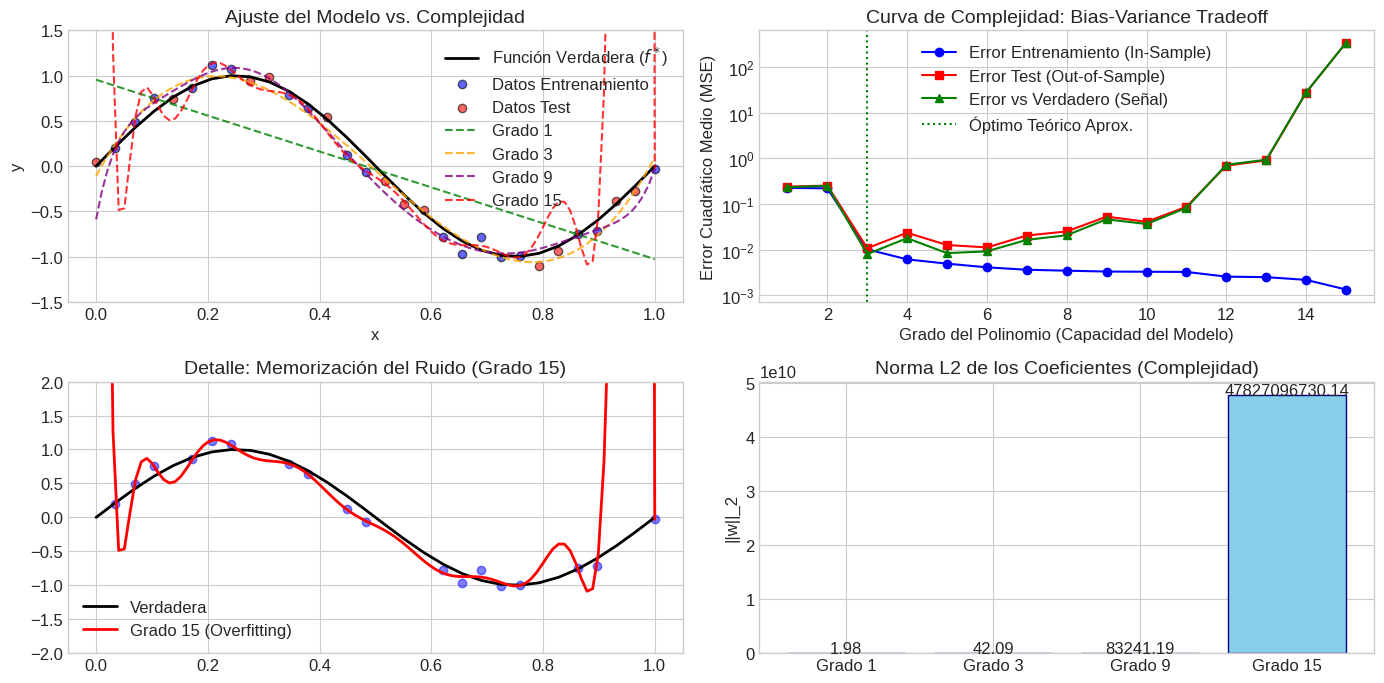

Grado      | MSE Train       | MSE Test        | MSE True Signal
------------------------------------------------------------
1          | 0.225362        | 0.239824        | 0.234136       
2          | 0.219911        | 0.252599        | 0.248367       
3          | 0.010154        | 0.010786        | 0.007990       
4          | 0.006125        | 0.023436        | 0.017824       
5          | 0.004938        | 0.012631        | 0.008390       
9          | 0.003315        | 0.052845        | 0.046186       
12         | 0.002564        | 0.690967        | 0.722804       
15         | 0.001340        | 340.129983      | 340.235574     


In [5]:
# Visualización
fig, axs = plt.subplots(2, 2, figsize=(14, 7))

# --- Plot A: Ajuste de Modelos (Underfitting vs Overfitting) ---
ax = axs[0, 0]
ax.plot(X, np.sin(2 * np.pi * X), 'k-', label='Función Verdadera ($f^*$)', linewidth=2)
ax.scatter(X_train, y_train, c='blue', label='Datos Entrenamiento', alpha=0.6, edgecolors='k')
ax.scatter(X_test, y_test, c='red', label='Datos Test', alpha=0.6, edgecolors='k')

colors = {1: 'green', 3: 'orange', 9: 'purple', 15: 'red'}
for d in specific_degrees:
    model = models_data[d]
    X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    ax.plot(X_plot, y_plot, label=f'Grado {d}', color=colors[d], linestyle='--', alpha=0.8)

ax.set_title('Ajuste del Modelo vs. Complejidad', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='upper right')
ax.set_ylim(-1.5, 1.5)

# --- Plot B: La Curva de Error (La Paradoja) ---
ax = axs[0, 1]
ax.plot(degrees, train_errors, 'o-', label='Error Entrenamiento (In-Sample)', color='blue')
ax.plot(degrees, test_errors, 's-', label='Error Test (Out-of-Sample)', color='red')
ax.plot(degrees, true_errors, '^-', label='Error vs Verdadero (Señal)', color='green')

ax.axvline(x=3, color='green', linestyle=':', label='Óptimo Teórico Aprox.')
ax.set_title('Curva de Complejidad: Bias-Variance Tradeoff', fontsize=14)
ax.set_xlabel('Grado del Polinomio (Capacidad del Modelo)')
ax.set_ylabel('Error Cuadrático Medio (MSE)')
ax.legend()
ax.set_yscale('log') # Escala log para apreciar mejor las diferencias

# --- Plot C: Detalle Overfitting (Grado 15) ---
ax = axs[1, 0]
ax.plot(X, np.sin(2 * np.pi * X), 'k-', label='Verdadera', linewidth=2)
ax.scatter(X_train, y_train, c='blue', alpha=0.5)
model_over = models_data[15]
X_plot = np.linspace(0, 1, 100).reshape(-1, 1)
ax.plot(X_plot, model_over.predict(X_plot), 'r-', label='Grado 15 (Overfitting)', linewidth=2)
ax.set_title('Detalle: Memorización del Ruido (Grado 15)', fontsize=14)
ax.legend()
ax.set_ylim(-2, 2)

# --- Plot D: Coeficientes del Modelo (Magnitud de Pesos) ---
ax = axs[1, 1]
degrees_coeffs = [1, 3, 9, 15]
width = 0.2
x_pos = np.arange(len(degrees_coeffs))

# Extraer coeficientes para ver la explosión de magnitud
coeffs_matrix = []
for d in degrees_coeffs:
    model = models_data[d]
    # Obtener coeficientes del paso lineal del pipeline
    coefs = model.named_steps['linear'].coef_
    coeffs_matrix.append(coefs)

# Plotear la norma L2 de los coeficientes como proxy de complejidad
norms = [np.linalg.norm(c) for c in coeffs_matrix]
ax.bar(x_pos, norms, color='skyblue', edgecolor='navy')
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Grado {d}' for d in degrees_coeffs])
ax.set_title('Norma L2 de los Coeficientes (Complejidad)', fontsize=14)
ax.set_ylabel('||w||_2')

for i, v in enumerate(norms):
    ax.text(i, v + 0.5, f'{v:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Impresión de métricas clave en consola
print(f"{'Grado':<10} | {'MSE Train':<15} | {'MSE Test':<15} | {'MSE True Signal':<15}")
print("-" * 60)
for i, d in enumerate(degrees):
    # Mostrar solo algunos puntos clave para no saturar
    if d in [1, 2, 3, 4, 5, 9, 12, 15]:
        print(f"{d:<10} | {train_errors[i]:<15.6f} | {test_errors[i]:<15.6f} | {true_errors[i]:<15.6f}")

In [6]:
import sklearn.linear_model
dir(sklearn.linear_model)

['ARDRegression',
 'BayesianRidge',
 'ElasticNet',
 'ElasticNetCV',
 'GammaRegressor',
 'HuberRegressor',
 'Lars',
 'LarsCV',
 'Lasso',
 'LassoCV',
 'LassoLars',
 'LassoLarsCV',
 'LassoLarsIC',
 'LinearRegression',
 'LogisticRegression',
 'LogisticRegressionCV',
 'MultiTaskElasticNet',
 'MultiTaskElasticNetCV',
 'MultiTaskLasso',
 'MultiTaskLassoCV',
 'OrthogonalMatchingPursuit',
 'OrthogonalMatchingPursuitCV',
 'PassiveAggressiveClassifier',
 'PassiveAggressiveRegressor',
 'Perceptron',
 'PoissonRegressor',
 'QuantileRegressor',
 'RANSACRegressor',
 'Ridge',
 'RidgeCV',
 'RidgeClassifier',
 'RidgeClassifierCV',
 'SGDClassifier',
 'SGDOneClassSVM',
 'SGDRegressor',
 'TheilSenRegressor',
 'TweedieRegressor',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_base',
 '_bayes',
 '_cd_fast',
 '_coordinate_descent',
 '_glm',
 '_huber',
 '_least_angle',
 '_linear_loss',
 '_logistic',
 '_omp',
 '_passiv